<center>

**РГР з теми "Елементи математичної статистики"**

**студентки групи КН-43**
**Басовської Марії Дмитрівни**

**Варіант №63**

</center>


---



# <center> **ХІД РОБОТИ**

Маємо вибірку із 100 загадкових чисел:

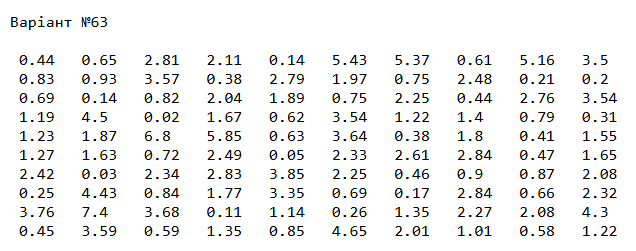

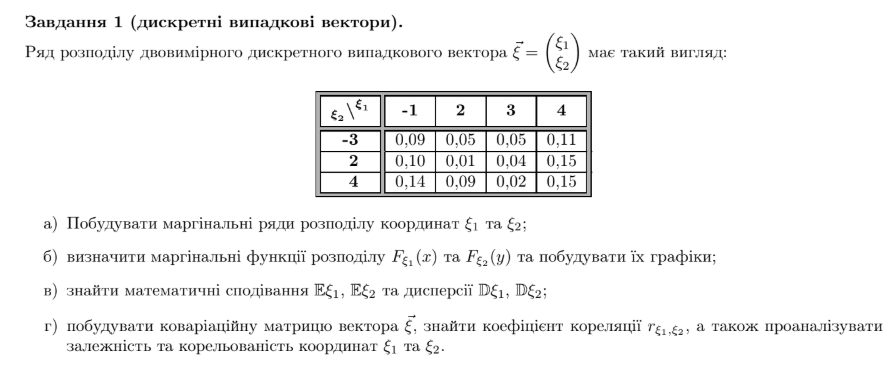

## **1. Первинний аналіз вибірки**

In [ ]:
# Спочатку імпортуємо потрібні бібліотеки

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
# Дані Варіанта №63
vibirka = '''
0.44, 0.65, 2.81, 2.11, 0.14, 5.43, 5.37, 0.61, 5.16, 3.5,
0.83, 0.93, 3.57, 0.38, 2.79, 1.97, 0.75, 2.48, 0.21, 0.2,
0.69, 0.14, 0.82, 2.04, 1.89, 0.75, 2.25, 0.44, 2.76, 3.54,
1.19, 4.5, 0.02, 1.67, 0.62, 3.54, 1.22, 1.4, 0.79, 0.31,
1.23, 1.87, 6.8, 5.85, 0.63, 3.64, 0.38, 1.8, 0.41, 1.55,
1.27, 1.63, 0.72, 2.49, 0.05, 2.33, 2.61, 2.84, 0.47, 1.65,
2.42, 0.03, 2.34, 2.83, 3.85, 2.25, 0.46, 0.9, 0.87, 2.08,
0.25, 4.43, 0.84, 1.77, 3.35, 0.69, 0.17, 2.84, 0.66, 2.32,
3.76, 7.4, 3.68, 0.11, 1.14, 0.26, 1.35, 2.27, 2.08, 4.3,
0.45, 3.59, 0.59, 1.35, 0.85, 4.65, 2.01, 1.01, 0.58, 1.22
'''

data = np.array([float(x.strip()) for x in vibirka.replace('\n', '').split(',') if x.strip()])

df = pd.DataFrame({'Початкові дані': data})
print(df)

    Початкові дані
0             0.44
1             0.65
2             2.81
3             2.11
4             0.14
..             ...
95            4.65
96            2.01
97            1.01
98            0.58
99            1.22

[100 rows x 1 columns]


Для аналізу використано вибірку обсягом $n=100$ спостережень.Значення ознаки належать інтервалу [0.02; 7.4]

Оскільки досліджувана ознака може набувати будь-яких дійсних значень на певному проміжку, вибірка має неперервний характер. Тому для її аналізу будується інтервальний статистичний ряд, гістограма та інтервальна емпірична функція розподілу.

###**Визначення кількості інтервалів**

На першому етапі побудуємо інтервальний статистичний ряд. Кількість інтервалів визначено за формулою Стерджеса:
$$
k=1+3.322log_{10}(n)
$$

Для n = 100:
$$
k=1+3.322log_{10}(100)≈8
$$

Інтервальний статистичний ряд дає змогу згрупувати спостереження за інтервалами та визначити частоти потрапляння значень у кожен із них. Для кожного інтервалу визначаються абсолютна частота та відносна частота.

Запишемо варіаційний ряд

In [ ]:
# 1. Первинний аналіз
n = len(data)
k = int(1 + 3.322 * np.log10(n))

counts, bins = np.histogram(data, bins=k)

# Статистичний ряд
intervals = [f"[{bins[i]:.2f}; {bins[i+1]:.2f})" for i in range(len(counts))]

stat_row = pd.DataFrame({
    'Інтервал': intervals,
    'Частота': counts,
    'Відносна частота': counts / n
})

print(stat_row)
print(f"Кількість спостережень: {len(data)}")

       Інтервал  Частота  Відносна частота
0  [0.02; 1.07)       41              0.41
1  [1.07; 2.13)       23              0.23
2  [2.13; 3.18)       16              0.16
3  [3.18; 4.24)       10              0.10
4  [4.24; 5.29)        5              0.05
5  [5.29; 6.35)        3              0.03
6  [6.35; 7.40)        2              0.02
Кількість спостережень: 100


## **2. Вибіркові характеристики**

Для кількісного опису вибірки обчислимо основні статистичні характеристики, які дозволяють оцінити положення центру розподілу, ступінь розсіювання даних та форму розподілу.

До основних вибіркових характеристик належать:

* вибіркове середнє $\bar{x}$ — характеризує центр розподілу;
* вибіркова дисперсія $D$ — характеризує розсіювання спостережень;
* виправлена вибіркова дисперсія $s^2$ — незміщена оцінка дисперсії генеральної сукупності;
* медіана $Me$ — значення, яке ділить впорядковану вибірку навпіл;
* мода $Mo$ — найбільш типове значення вибірки;
* коефіцієнт асиметрії — характеризує симетричність розподілу;
* коефіцієнт ексцесу — характеризує ступінь загостреності розподілу.

In [ ]:
# 2. Вибіркові характеристики
mean = np.mean(data)
var = np.var(data)
adj_var = np.var(data, ddof=1)
median = np.median(data)

mode_index = np.argmax(counts)

mode_lower = bins[mode_index]
mode_upper = bins[mode_index + 1]

mode_est = (mode_lower + mode_upper) / 2
skewness = stats.skew(data)
kurtosis = stats.kurtosis(data)

print(f"Середнє: {mean:.4f}")
print(f"Дисперсія: {var:.4f}")
print(f"Виправлена дисперсія: {adj_var:.4f}")
print(f"Медіана: {median:.4f}")
print(f"Модальний інтервал: [{mode_lower:.4f}; {mode_upper:.4f})")
print(f"Оцінка моди: {mode_est:.4f}")
print(f"Асиметрія: {skewness:.4f}")
print(f"Ексцес: {kurtosis:.4f}")

Середнє: 1.8913
Дисперсія: 2.5405
Виправлена дисперсія: 2.5662
Медіана: 1.4750
Модальний інтервал: [0.0200; 1.0743)
Оцінка моди: 0.5471
Асиметрія: 1.1663
Ексцес: 1.0655


Коефіцієнт асиметрії має додатне значення $As>0$. Це свідчить про правосторонню асиметрію, тобто більшість спостережень зосереджена біля менших значень, а "хвіст" розподілу витягнутий праворуч.

Коефіцієнт ексцесу також є додатним $Ex>0$. Це означає, що розподіл є більш загостреним порівняно з нормальним та має більш виражену концентрацію значень поблизу центру.

Додатковим підтвердженням правосторонньої асиметрії є співвідношення між основними характеристиками положення:
$$
Mo<Me<\bar x
$$
Для правосторонньо асиметричних розподілів характерно, що середнє значення перевищує медіану, а медіана перевищує моду.


Обчислені вибіркові характеристики свідчать про те, що вибірка має додатну асиметрію, підвищену загостреність та концентрацію більшості значень у лівій частині області визначення. Отримані результати узгоджуються з припущенням про експоненційний характер розподілу генеральної сукупності.

## **3. Висунення гіпотези**
На основі результатів первинного аналізу вибірки висувається гіпотеза щодо закону розподілу генеральної сукупності. За результатами побудови гістограми, інтервальної емпіричної функції розподілу та аналізу вибіркових характеристик встановлено такі особливості вибірки: *усі значення є додатними, найбільша концентрація спостережень припадає на область малих значень, зі збільшенням значення ознаки частота спостережень поступово зменшується, коефіцієнт асиметрії є додатним, гістограма має виражений правий хвіст*.

Такі властивості характерні для експоненційного розподілу, тому висувається нульова гіпотеза:
$$
H_0:X∼Exp(λ)
$$
де $\lambda > 0$ — невідомий параметр інтенсивності.

Щільність експоненційного розподілу має вигляд:
$$
f(x)=λe^{−λx},x≥0
$$
$$
f(x)=0,x<0
$$


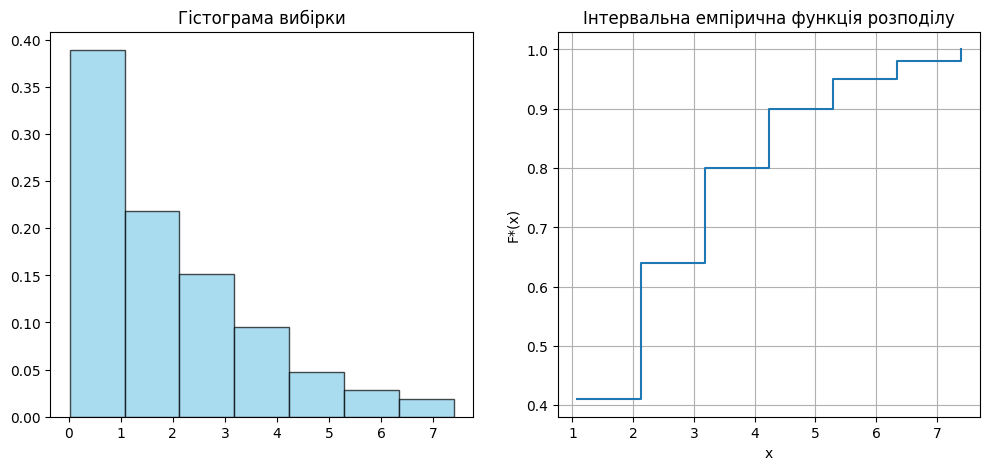

In [ ]:
# Візуалізація
plt.figure(figsize=(12, 5))

# Гістограма
plt.subplot(1, 2, 1)
plt.hist(data, bins=k, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title("Гістограма вибірки")

# Емпірична функція розподілу
plt.subplot(1, 2, 2)
cumulative_freq = np.cumsum(counts) / n

plt.step(bins[1:], cumulative_freq, where='post')
plt.title("Інтервальна емпірична функція розподілу")
plt.xlabel("x")
plt.ylabel("F*(x)")
plt.grid(True)
plt.show()

Побудована гістограма демонструє характерну для експоненційного розподілу форму - максимальна частота спостерігається в області малих значень, після чого частота поступово спадає.

Інтервальна емпірична функція розподілу також узгоджується з цією гіпотезою - вона швидко зростає на початкових ділянках та поступово уповільнює зростання зі збільшенням значення ознаки.

Це відповідає властивостям експоненційного закону розподілу, для якого ймовірність появи великих значень швидко зменшується.

Для експоненційного розподілу характерні такі властивості:
* область визначення: $x≥0$
* математичне сподівання: $E(X)=\frac{1}{\lambda}$
* дисперсія: $D(X)=\frac{1}{\lambda^2}$

Оскільки всі спостереження є додатними, а форма вибіркового розподілу узгоджується з переліченими властивостями, експоненційна модель є природною кандидатурою для опису досліджуваної генеральної сукупності.

На даному етапі найбільш обґрунтованою є гіпотеза про те, що генеральна сукупність має експоненційний закон розподілу з невідомим параметром $\lambda$, яка буде перевірена далі за допомогою критерію узгодженості Пірсона $\chi^2$.

## **4. Оцінювання параметра**
Розглядається експоненційний розподіл з щільністю:
$$
f(x)=λe^{−λx},x≥0
$$
де $\lambda > 0$ — невідомий параметр інтенсивності.


**Метод моментів**

Теоретичне математичне сподівання експоненційного розподілу:
$$
E(X)=\frac{1}{\lambda}
$$​

Прирівнюємо його до вибіркового середнього:
$$
\bar x=\frac{1}{\lambda}
$$

Звідси отримаємо оцінку параметра:
$$
\hat λ_{MM}=\frac{1}{\bar x}
$$

**Метод максимальної правдоподібності**

Нехай $X_1, X_2, ..., X_n$ — вибірка з експоненційного розподілу.

Функція правдоподібності:
$$
L(λ)=λ^ne^{−λ\sum_{i=1}^{n}​x_i}
$$

Логарифмічна функція правдоподібності:
$$
\ln L(λ)=n\ln λ-λ \sum_{i=1}^{n}​x_i
$$

Звідси оцінка максимальної правдоподібності:
$$
\hat{\lambda}_{MM}=\frac{1}{\bar x}.
$$

In [ ]:
# 4. Оцінка параметрів (для експоненційного розподілу lambda = 1/mean)
lambda_est = 1 / mean
print(f"Оцінка параметра lambda: {lambda_est:.4f}")

Оцінка параметра lambda: 0.5287


Оцінка $\hat{\lambda}=\frac{1}{\bar{x}}$ має властивості асимптотичної незміщеності, конзистентності (за законом великих чисел), асимптотичної ефективності (досягає межі Рао–Крамера).

Обидва методи оцінювання (метод моментів і метод максимальної правдоподібності) дають однаковий результат, що підтверджує коректність обраної моделі та стабільність оцінки параметра $\lambda$.

## **5. Аналіз властивостей оцінки**

Оскільки параметр експоненційного розподілу оцінюється як $\hat{\lambda} = 1/\bar{x}$, розглянемо властивості цієї оцінки.

Оцінка $\hat{\lambda} = 1/\bar{x}$ є асимптотично незміщеною, тобто $E(\hat{\lambda}) \to \lambda$ при $n \to \infty$

За законом великих чисел: $\bar{x} \xrightarrow{P} E(X)=1/\lambda$
, тоді: $\hat{\lambda} = 1/\bar{x} \xrightarrow{P} \lambda$. Отже оцінка є конзистентною.

Оцінка $\hat{\lambda}$ є асимптотично ефективною, оскільки досягає межі Рао–Крамера при великих $n$.


## **6. Довірчий інтервал**

Для оцінювання невідомого параметра експоненційного розподілу $\lambda$ будується довірчий інтервал з рівнем надійності 0.95.

Оскільки досліджувана вибірка має достатньо великий обсяг ($n = 100$), для побудови інтервалу використовується точний підхід, оснований на розподілі $\chi^2$.

Відомо, що якщо випадкова величина $X$ має експоненційний розподіл з параметром $\lambda$, то виконується співвідношення:

$$2\lambda \sum_{i=1}^{n} X_i \sim \chi^2_{2n}$$

Це дозволяє побудувати точний довірчий інтервал для параметра $\lambda$ без використання нормальної апроксимації.

На основі цієї властивості межі довірчого інтервалу визначаються через квантили розподілу $\chi^2$:

* нижня межа відповідає верхньому значенню статистики $\chi^2$;
* верхня межа відповідає нижньому значенню статистики $\chi^2$.

Таким чином, інтервал має вигляд:

$$\lambda_{low} = \frac{\chi^2_{\alpha/2,,2n}}{2\sum X_i}$$

$$\lambda_{high} = \frac{\chi^2_{1-\alpha/2,,2n}}{2\sum X_i}$$

Для даної вибірки при рівні значущості $\alpha = 0.05$ (довірча ймовірність 0.95) було отримано числові межі інтервалу.

Після підстановки значень з вибірки отримуємо:

$$[\lambda_{low}; \lambda_{high}] = [0.4302; 0.6373]$$

Отриманий довірчий інтервал означає, що з імовірністю 0.95 істинне значення параметра $\lambda$ експоненційного розподілу, який описує досліджувану генеральну сукупність, знаходиться в межах [0.4302; 0.6373]. Довірчий інтервал є достатньо вузьким, що свідчить про високу точність оцінки параметра. Це додатково підтверджує стабільність моделі експоненційного розподілу для опису даної вибірки.


## **7. Перевірка гіпотези χ²**

Для перевірки гіпотези про закон розподілу генеральної сукупності використовується критерій узгодженості Пірсона $\chi^2$.

На попередніх етапах була висунута нульова гіпотеза:

$$H_0: X \sim Exp(\lambda)$$

Альтернативна гіпотеза:

$$H_1: X \not\sim Exp(\lambda)$$

Критерій $\chi^2$ ґрунтується на порівнянні емпіричних і теоретичних частот.
* емпіричні частоти $O_i$ — це фактична кількість спостережень у кожному інтервалі;
* теоретичні частоти $E_i$ — це кількість спостережень, яка очікується при експоненційному розподілі з оціненим параметром $\lambda$.

Чим менша різниця між $O_i$ та $E_i$, тим краще модель описує дані.

Ймовірність попадання в інтервал $(x_i, x_{i+1}]$ визначається через функцію розподілу:

$$P_i = F(x_{i+1}) - F(x_i)$$

Тоді теоретична частота:

$$E_i = n \cdot P_i$$

Статистика Пірсона обчислюється за формулою:

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

де:

* $O_i$ — емпіричні частоти,
* $E_i$ — теоретичні частоти.



In [ ]:
# 7. Критерій Хі-квадрат
# Очікувані частоти для Exp(1/lambda)
exp_dist = stats.expon(scale=mean)
expected_freq = []

for i in range(len(bins)-1):
    p = exp_dist.cdf(bins[i+1]) - exp_dist.cdf(bins[i])
    expected_freq.append(p * n)

expected_freq = np.array(expected_freq)

# нормування
expected_freq *= counts.sum() / expected_freq.sum()

chi2_stat, p_val = stats.chisquare(f_obs=counts, f_exp=expected_freq, ddof=1)

print(f"Chi2 Stat: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4f}")

alpha = 0.05
chi2_low = stats.chi2.ppf(alpha/2, 2*n)
chi2_high = stats.chi2.ppf(1-alpha/2, 2*n)

lambda_low = chi2_low / (2*np.sum(data))
lambda_high = chi2_high / (2*np.sum(data))

print(f"95% ДІ для λ: [{lambda_low:.4f}; {lambda_high:.4f}]")
if p_val > alpha:
    print("Нульова гіпотеза не відхиляється")
else:
    print("Нульова гіпотеза відхиляється")

Chi2 Stat: 1.1093
P-value: 0.9533
95% ДІ для λ: [0.4302; 0.6373]
Нульова гіпотеза не відхиляється


Оскільки виконується умова $p > \alpha$, немає підстав відхиляти нульову гіпотезу $H_0$. Отримане значення $p$ є дуже великим, що свідчить про незначну різницю між емпіричними та теоретичними частотами. Це означає, що експоненційна модель добре узгоджується з експериментальними даними.

На основі критерію $\chi^2$ нульова гіпотеза про експоненційний закон розподілу не відхиляється. Отже, можна зробити висновок, що вибірка статистично узгоджується з моделлю $Exp(\lambda)$ з параметром, оціненим за даними.


## **8. Висновок**

У ході виконання розрахунково-графічної роботи було проведено статистичний аналіз вибірки обсягом $n = 100$ спостережень, яка моделює значення з деякої генеральної сукупності з невідомим законом розподілу.

На першому етапі було побудовано інтервальний статистичний ряд, гістограму частот та інтервальну емпіричну функцію розподілу. Це дозволило візуально оцінити характер розподілу даних.

Обчислені вибіркові характеристики (середнє, дисперсія, медіана, мода, коефіцієнти асиметрії та ексцесу) показали, що розподіл є правосторонньо асиметричним та має підвищену концентрацію значень у області малих значень.

На основі отриманих результатів була висунута гіпотеза про те, що генеральна сукупність має експоненційний закон розподілу:

$$H_0: X \sim Exp(\lambda)$$

Параметр $\lambda$ було оцінено двома методами — методом моментів та методом максимальної правдоподібності. У результаті отримано однакову оцінку:

$$\hat{\lambda} = 0.5287$$

що свідчить про стабільність та узгодженість оцінювання.

Додатково було побудовано 95%-й довірчий інтервал для параметра $\lambda$, який підтвердив достатню точність оцінки.

Перевірка гіпотези за критерієм узгодженості Пірсона $\chi^2$ показала, що статистично значущих підстав для відхилення нульової гіпотези не виявлено ($p = 0.9533$).

Таким чином, експоненційна модель з параметром $\lambda$, оціненим за вибіркою, є адекватним описом досліджуваних даних і може бути використана для подальшого аналізу.